## Feature Engineering Demos

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

insurance_df = pd.read_csv("insurance.csv")

In [14]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
def value_counter(dataframe):
    value_series = pd.DataFrame()
    for col in dataframe.select_dtypes(["object"]).columns:
        print(dataframe[col].value_counts())

value_counter(insurance_df)

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


C:\Users\Daffa\AppData\Local\Temp\ipykernel_17260\2715946592.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in dataframe.select_dtypes(["object"]).columns:


In [16]:
def cat_plotter(data, target):
    import matplotlib.pyplot as plt
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(data=data, x=col, y=target)
        plt.xticks(rotation=45)
        plt.show()



C:\Users\Daffa\AppData\Local\Temp\ipykernel_17260\1770102094.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(["object"]).columns:


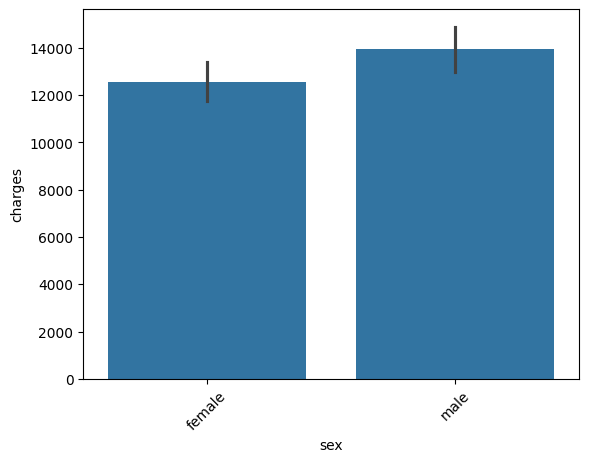

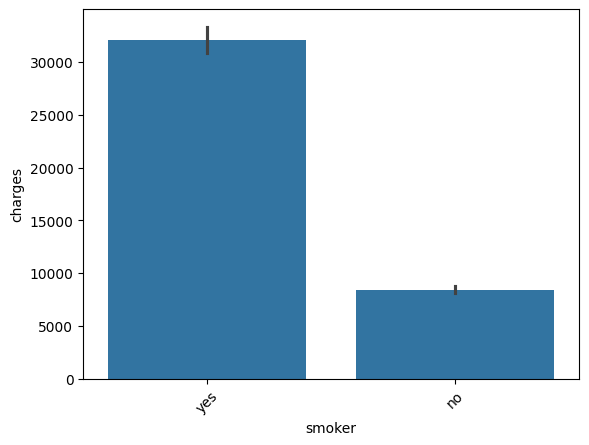

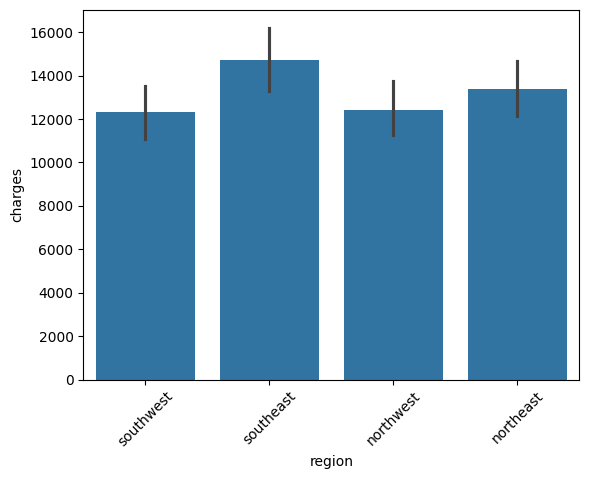

In [17]:
cat_plotter(insurance_df, "charges")

In [18]:
region_dict = {
    "northwest": "west",
    "southwest": "west",
    "northeast": "east",
    "southeast": "east",
}

insurance_df["region_group"] = insurance_df["region"].map
(region_dict)

insurance_df["region_group"].value_counts()

region_group
<bound method Series.map of 0       southwest\n1       southeast\n2       southeast\n3       northwest\n4       northwest\n          ...    \n1333    northwest\n1334    northeast\n1335    southeast\n1336    southwest\n1337    northwest\nName: region, Length: 1338, dtype: str>    1338
Name: count, dtype: int64

In [19]:
insurance_df["has_child"] = np.where(insurance_df["children"] > 0, 1, 0)

insurance_df["has_child"].value_counts()

has_child
1    764
0    574
Name: count, dtype: int64

In [20]:
insurance_df =  insurance_df.drop(["region", "sex"], axis=1)


In [21]:
insurance_df = (
    pd.get_dummies(insurance_df, drop_first=True).assign(
       age_sq = insurance_df["age"]**2,
       )
)

X = sm.add_constant(insurance_df.drop(["charges"], axis=1))
y = insurance_df["charges"]

X, X_test, y, y_test = train_test_split(X, y, test_size=.2, random_state=2023)

X.head()

,const,age,bmi,children,has_child,smoker_yes,age_sq
1068,1.0,63,21.660,1,1,False,3969
1018,1.0,54,35.815,3,1,False,2916
995,1.0,39,23.275,3,1,False,1521
1248,1.0,18,39.820,0,0,False,324
549,1.0,43,46.200,0,0,True,1849
